# 03 — Data Pipeline & Cleaning
Merge all raw sources, compute features, handle nulls, and build the `model_ready` table in SQLite.

**Run notebook 01 first** to populate the raw parquet files and SQLite tables.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
from src.fetchers.nfl_fetcher import fetch_seasonal_stats, fetch_rosters, fetch_snap_counts
from src.fetchers.sleeper_fetcher import fetch_players
from src.pipeline.cleaner import build_clean_dataset, read_from_db
from src.pipeline.features import build_model_dataset

pd.set_option('display.max_columns', 40)

## 1. Load Raw Data (from per-season checkpoints)

In [2]:
seasonal = fetch_seasonal_stats()
rosters = fetch_rosters()
snap_counts = fetch_snap_counts()
sleeper_players = fetch_players()

print(f'Seasonal:    {seasonal.shape}')
print(f'Rosters:     {rosters.shape}')
print(f'Snap counts: {snap_counts.shape}')
print(f'Sleeper:     {sleeper_players.shape}')

  [1/13] 2012 — loaded from checkpoint
  [2/13] 2013 — loaded from checkpoint
  [3/13] 2014 — loaded from checkpoint
  [4/13] 2015 — loaded from checkpoint
  [5/13] 2016 — loaded from checkpoint
  [6/13] 2017 — loaded from checkpoint
  [7/13] 2018 — loaded from checkpoint
  [8/13] 2019 — loaded from checkpoint
  [9/13] 2020 — loaded from checkpoint
  [10/13] 2021 — loaded from checkpoint
  [11/13] 2022 — loaded from checkpoint
  [12/13] 2023 — loaded from checkpoint
  [13/13] 2024 — loaded from checkpoint
Combined seasonal stats: 7870 rows saved to /home/ruppdj/claude_testing/fantasy_football/src/fetchers/../../data/raw/seasonal_stats.parquet
Loading rosters from cache: /home/ruppdj/claude_testing/fantasy_football/src/fetchers/../../data/raw/rosters.parquet
  [1/13] 2012 — loaded from checkpoint
  [2/13] 2013 — loaded from checkpoint
  [3/13] 2014 — loaded from checkpoint
  [4/13] 2015 — loaded from checkpoint
  [5/13] 2016 — loaded from checkpoint
  [6/13] 2017 — loaded from checkpoin

## 2. Run Cleaning Pipeline
Merges all sources, computes age, loads `nfl_stats` table to SQLite.

In [3]:
clean_df = build_clean_dataset(
    seasonal_df=seasonal,
    rosters_df=rosters,
    sleeper_df=sleeper_players,
    snap_df=snap_counts,
)
print(f'\nClean dataset: {clean_df.shape}')
clean_df.head(3)

Cleaning seasonal stats...
Merging roster metadata...
Merging Sleeper metadata...
Merging snap pct...
Computing age at season...
Loading raw tables to SQLite...
Loaded 5711 rows into table 'nfl_stats'
Clean dataset: 5711 rows, 72 columns

Clean dataset: (5711, 72)


,player_id,season,season_type,completions,attempts,passing_yards,passing_tds,interceptions,sacks,sack_yards,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_2pt_conversions,pacr,dakota,carries,...,rfd_sh,rtdfd_sh,dom,w8dom,yptmpa,ppr_sh,full_name,position,birth_date,height,weight,college,sleeper_id,pfr_id,status,injury_status,depth_chart_order,search_rank,avg_snap_pct,age_at_season
0,00-0004541,2012,REG,0,0,0.0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.00000,0,0.000000,0.000000,0,...,0.041667,0.048951,0.059820,0.043537,0.244444,0.030938,Donald Driver,WR,1975-02-02,72.0,194.0,Alcorn State,None,DrivDo00,NaN,NaN,NaN,NaN,NaN,37.6
1,00-0006101,2012,REG,0,0,0.0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.00000,0,0.000000,0.000000,0,...,0.264228,0.262590,0.223538,0.207661,1.512195,0.148255,Tony Gonzalez,TE,1976-02-27,77.0,247.0,California,None,GonzTo00,NaN,NaN,NaN,NaN,NaN,36.5
2,00-0007091,2012,REG,138,221,1367.0,7,5.0,14.0,103.0,2,1,1707.0,557.0,71.0,-14.85631,1,6.316032,0.371353,13,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.120407,Matt Hasselbeck,QB,1975-09-25,76.0,235.0,Boston College,36,HassMa00,Inactive,None,NaN,9999999.0,NaN,36.9


## 3. Inspect Merged Dataset

In [4]:
print('Columns:')
print(clean_df.columns.tolist())

Columns:
['player_id', 'season', 'season_type', 'completions', 'attempts', 'passing_yards', 'passing_tds', 'interceptions', 'sacks', 'sack_yards', 'sack_fumbles', 'sack_fumbles_lost', 'passing_air_yards', 'passing_yards_after_catch', 'passing_first_downs', 'passing_epa', 'passing_2pt_conversions', 'pacr', 'dakota', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_fumbles', 'rushing_fumbles_lost', 'rushing_first_downs', 'rushing_epa', 'rushing_2pt_conversions', 'receptions', 'targets', 'receiving_yards', 'receiving_tds', 'receiving_fumbles', 'receiving_fumbles_lost', 'receiving_air_yards', 'receiving_yards_after_catch', 'receiving_first_downs', 'receiving_epa', 'receiving_2pt_conversions', 'racr', 'target_share', 'air_yards_share', 'wopr_x', 'special_teams_tds', 'fantasy_points', 'fantasy_points_ppr', 'games', 'tgt_sh', 'ay_sh', 'yac_sh', 'wopr_y', 'ry_sh', 'rtd_sh', 'rfd_sh', 'rtdfd_sh', 'dom', 'w8dom', 'yptmpa', 'ppr_sh', 'full_name', 'position', 'birth_date', 'height', 'weight', '

In [5]:
# Null rates after cleaning
null_rates = clean_df.isna().mean().sort_values(ascending=False)
print('Null rates (top 15):')
print(null_rates[null_rates > 0].head(15))

Null rates (top 15):
injury_status        0.998249
depth_chart_order    0.765715
avg_snap_pct         0.076169
search_rank          0.026966
status               0.026615
sleeper_id           0.026440
pfr_id               0.004903
age_at_season        0.003502
college              0.003502
weight               0.003502
height               0.003502
birth_date           0.003502
position             0.003502
full_name            0.003502
w8dom                0.000525
dtype: float64


In [6]:
# Age at season sample
if 'age_at_season' in clean_df.columns:
    print('Age stats:')
    print(clean_df['age_at_season'].describe())

# Verify sleeper join rate
if 'sleeper_id' in clean_df.columns and 'status' in clean_df.columns:
    join_rate = clean_df['status'].notna().mean()
    print(f'\nSleeper join rate: {join_rate:.1%}')

# Snap count coverage
if 'avg_snap_pct' in clean_df.columns:
    snap_coverage = clean_df['avg_snap_pct'].notna().mean()
    print(f'Snap count join rate: {snap_coverage:.1%}')

Age stats:
count    5691.000000
mean       26.395853
std         3.313167
min        20.600000
25%        23.900000
50%        25.700000
75%        28.200000
max        45.100000
Name: age_at_season, dtype: float64

Sleeper join rate: 97.3%
Snap count join rate: 92.4%


## 4. Run Feature Engineering
Adds lagged PPR, next-year target, usage metrics, position dummies.
Saves `model_ready` table to SQLite.

In [7]:
model_df = build_model_dataset(clean_df)
print(f'\nModel-ready dataset: {model_df.shape}')
model_df.head(3)

Adding lagged PPR features...
Adding target variable...
Adding usage features...
Encoding position...
Selecting model features...
Model-ready dataset: 4058 rows, 24 columns
Saving model_ready table to SQLite...
Saved 4058 rows to model_ready table

Model-ready dataset: (4058, 24)


,player_id,full_name,position,season,ppr_pts_next,age_at_season,ppr_pts_prev1,ppr_pts_prev2,fantasy_points_ppr,ppr_per_game,td_rate,target_share,air_yards_share,targets_per_game,carries_per_game,avg_snap_pct,receiving_epa,rushing_epa,passing_epa,racr,pos_QB,pos_RB,pos_WR,pos_TE
1,00-0006101,Tony Gonzalez,TE,2012,218.90,36.5,NaN,NaN,234.00,14.625,0.500,3.171097,3.236721,7.75,0.000,NaN,61.123664,0.000000,0.000000,16.35189,0,0,0,1
2,00-0007091,Matt Hasselbeck,QB,2012,16.94,36.9,NaN,NaN,76.48,9.560,0.875,0.000000,0.000000,0.00,1.625,NaN,0.000000,-3.944240,-14.856310,0.00000,1,0,0,0
847,00-0007091,Matt Hasselbeck,QB,2014,91.10,38.9,76.48,NaN,16.94,4.235,0.500,0.000000,0.000000,0.00,2.000,0.305,0.000000,-7.756981,-0.628051,0.00000,1,0,0,0


## 5. Validate Model Dataset

In [8]:
# No nulls in target or age
assert model_df['ppr_pts_next'].isna().sum() == 0, 'Target has nulls!'
assert model_df['age_at_season'].isna().sum() == 0, 'age_at_season has nulls!'
print('Validation passed: target and age have no nulls')

print(f'\nSeason range: {model_df["season"].min()} – {model_df["season"].max()}')
print('\nRows per season:')
print(model_df['season'].value_counts().sort_index())

print('\nRows per position:')
print(model_df['position'].value_counts())

Validation passed: target and age have no nulls

Season range: 2012 – 2023

Rows per season:
2012    319
2013    327
2014    339
2015    334
2016    333
2017    335
2018    342
2019    350
2020    354
2021    354
2022    340
2023    331
Name: season, dtype: int64

Rows per position:
WR    1546
RB    1144
TE     862
QB     506
Name: position, dtype: int64


In [9]:
# Null rates in model features
feature_cols = [
    'age_at_season', 'years_exp', 'ppr_pts_prev1', 'ppr_pts_prev2',
    'fantasy_points_ppr', 'target_share', 'air_yards_share', 'avg_snap_pct',
]
available = [c for c in feature_cols if c in model_df.columns]
print('Feature null rates:')
print(model_df[available].isna().mean().sort_values(ascending=False))

Feature null rates:
ppr_pts_prev2         0.507146
ppr_pts_prev1         0.298423
avg_snap_pct          0.080089
age_at_season         0.000000
fantasy_points_ppr    0.000000
target_share          0.000000
air_yards_share       0.000000
dtype: float64


## 6. Target Variable Distribution

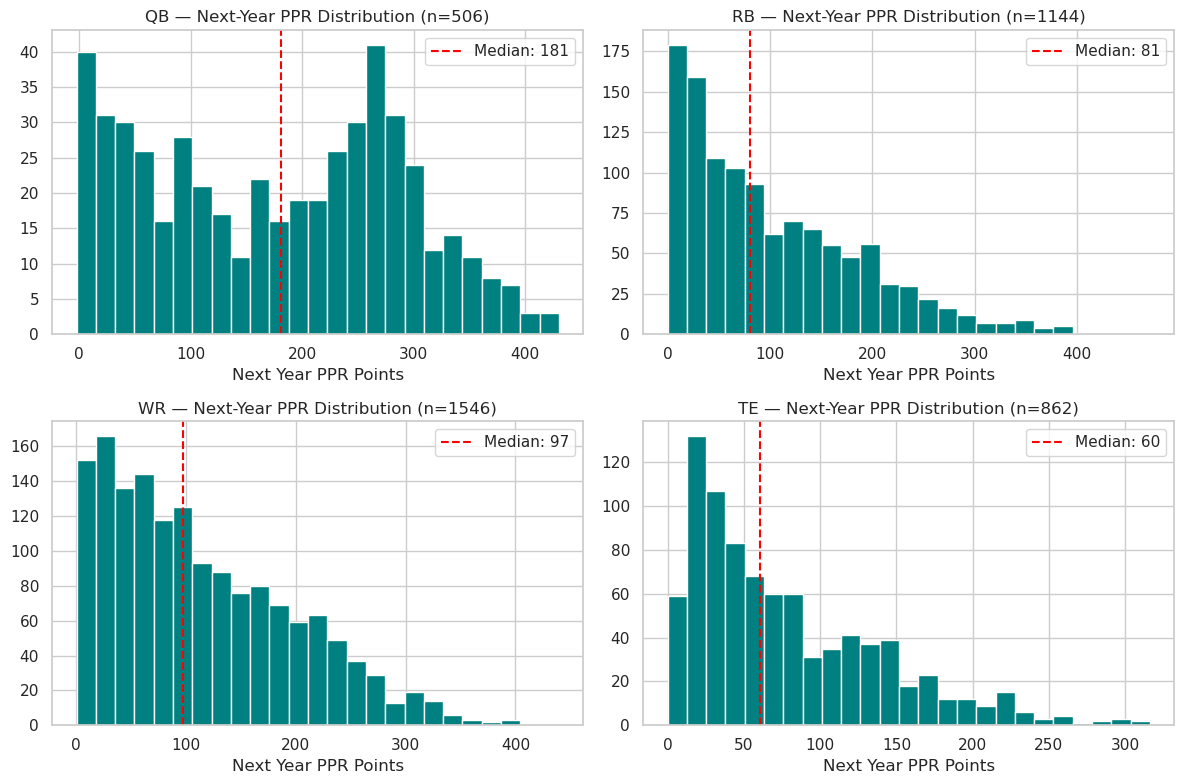

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, pos in zip(axes.flatten(), ['QB', 'RB', 'WR', 'TE']):
    sub = model_df[model_df['position'] == pos]['ppr_pts_next'].dropna()
    ax.hist(sub, bins=25, edgecolor='white', color='teal')
    ax.set_title(f'{pos} — Next-Year PPR Distribution (n={len(sub)})')
    ax.set_xlabel('Next Year PPR Points')
    ax.axvline(sub.median(), color='red', linestyle='--', label=f'Median: {sub.median():.0f}')
    ax.legend()
plt.tight_layout()
plt.show()